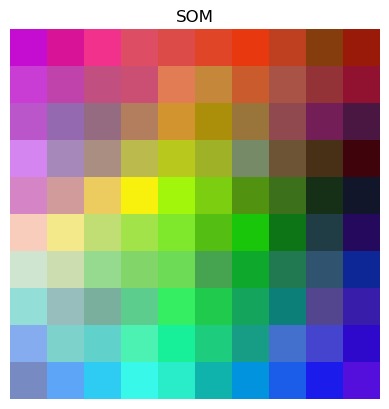

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class SOM:
    def __init__(self, dim, size, lr=0.1, radius=None, epochs=500):
        self.dim, self.size = dim, size
        self.lr, self.epochs = lr, epochs
        self.radius = radius if radius else max(size)/2
        self.weights = np.random.rand(size[0], size[1], dim)

    def bmu(self, x):
        d = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(d), d.shape)

    def update(self, x, bmu):
        for i in range(self.size[0]):
            for j in range(self.size[1]):
                dist = np.linalg.norm([i-bmu[0], j-bmu[1]])
                if dist <= self.radius:
                    influence = np.exp(-dist**2/(2*self.radius**2))
                    self.weights[i,j] += self.lr*influence*(x-self.weights[i,j])

    def train(self, data):
        for _ in range(self.epochs):
            for x in data:
                self.update(x, self.bmu(x))
            self.lr *= 0.99; self.radius *= 0.99

    def show(self):
        plt.imshow(self.weights.reshape(self.size[0], self.size[1], self.dim))
        plt.axis("off"); plt.title("SOM"); plt.show()

# Example
data = np.random.rand(200, 3)   # 200 samples, 3 features (like RGB)
som = SOM(dim=3, size=(10,10))
som.train(data)
som.show()